# Données OpenStreetMap

`OSM` interroge OpenStreetMap (via `osmnx` / l'API Overpass) et renvoie un
`GeoDataFrame` en EPSG:4326.

`get_data(place, tags, data_type)` :

- **place** : un nom de lieu (`str`), une bbox `(ouest, sud, est, nord)`, ou
  un `GeoDataFrame` polygonal ;
- **tags** : un dictionnaire de tags OSM, ex. `{"building": True}`,
  `{"amenity": ["restaurant", "cafe"]}` ;
- **data_type** : `"points"`, `"lines"`, `"polygons"` ou `"all"`.

Les exemples portent sur **Grand-Bassam** (Côte d'Ivoire). Le premier appel
sur une zone peut prendre une à quelques minutes (Overpass) ; les suivants
sont mis en cache par `osmnx`. Pour une emprise plus serrée, utilisez une
bbox ou un `GeoDataFrame` (voir la fin du notebook).

In [1]:
import logging
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))  # cartograpy est à la racine du dépôt
logging.basicConfig(level=logging.INFO, format="%(message)s")

import cartograpy as cp
from cartograpy.data import OSM

osm = OSM()
PLACE = "Grand-Bassam, Côte d'Ivoire"

C:\Users\Ordinateur\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\importlib\metadata\__init__.py:467: DeprecationWarning: Implicit None on return values is deprecated and will raise KeyErrors.
  return self.metadata['Version']


## Découvrir les tags

`list_tags`, `search_tags` et `get_common_tag` aident à trouver la bonne
combinaison clé/valeur sans quitter le notebook.

In [2]:
osm.get_common_tag()

{'restaurants': {'amenity': 'restaurant'},
 'schools': {'amenity': 'school'},
 'hospitals': {'amenity': 'hospital'},
 'parks': {'leisure': 'park'},
 'supermarkets': {'shop': 'supermarket'},
 'hotels': {'tourism': 'hotel'},
 'gas_stations': {'amenity': 'fuel'},
 'pharmacies': {'amenity': 'pharmacy'},
 'banks': {'amenity': 'bank'},
 'cafes': {'amenity': 'cafe'},
 'museums': {'tourism': 'museum'},
 'primary_roads': {'highway': ['primary', 'trunk', 'motorway']},
 'residential_buildings': {'building': 'residential'},
 'commercial_buildings': {'building': 'commercial'},
 'rivers': {'waterway': 'river'},
 'forests': {'landuse': 'forest'},
 'beaches': {'natural': 'beach'},
 'train_stations': {'railway': 'station'},
 'bus_stops': {'highway': 'bus_stop'},
 'parking': {'amenity': 'parking'}}

In [3]:
osm.list_tags("tourism", show_examples=True)

{'description': 'Sites touristiques et hébergements',
 'tags': {'tourism': ['hotel',
   'museum',
   'attraction',
   'viewpoint',
   'information',
   'camp_site',
   'guest_house',
   'hostel',
   'monument',
   'artwork'],
  'historic': ['castle', 'monument', 'memorial', 'archaeological_site']},
 'example': {'tourism': 'museum', 'name': 'Louvre'}}

## Routes (lignes)

`{"highway": True}` récupère toutes les voies ; on garde les lignes.

In [4]:
routes = osm.get_data(PLACE, {"highway": True}, data_type="lines")
print(len(routes), "tronçons")
routes["highway"].value_counts().head(10)

3901 tronçons


highway
residential     2736
track            350
unclassified     264
service          257
path             109
trunk             64
tertiary          52
footway           34
secondary         11
trunk_link        10
Name: count, dtype: int64

🧭 Flèche du Nord ajoutée (map-utils)


📊 Centrage intelligent appliqué:


   Format: Personnalisé (N/A)


   Ratio figure: 1.50


   Ratio données: 1.21


   Étendue: [-4.00, -3.16, 5.13, 5.68]


C:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\matplotlib_map_utils\core\scale_bar.py:781: UserWarning: Provided CRS EPSG:4326 uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.
  warnings.warn(f"Provided CRS {bar_projection} uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.")
C:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\matplotlib_map_utils\core\scale_bar.py:781: UserWarning: Provided CRS EPSG:4326 uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.
  warnings.warn(f"Provided CRS {bar_projection} uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.")


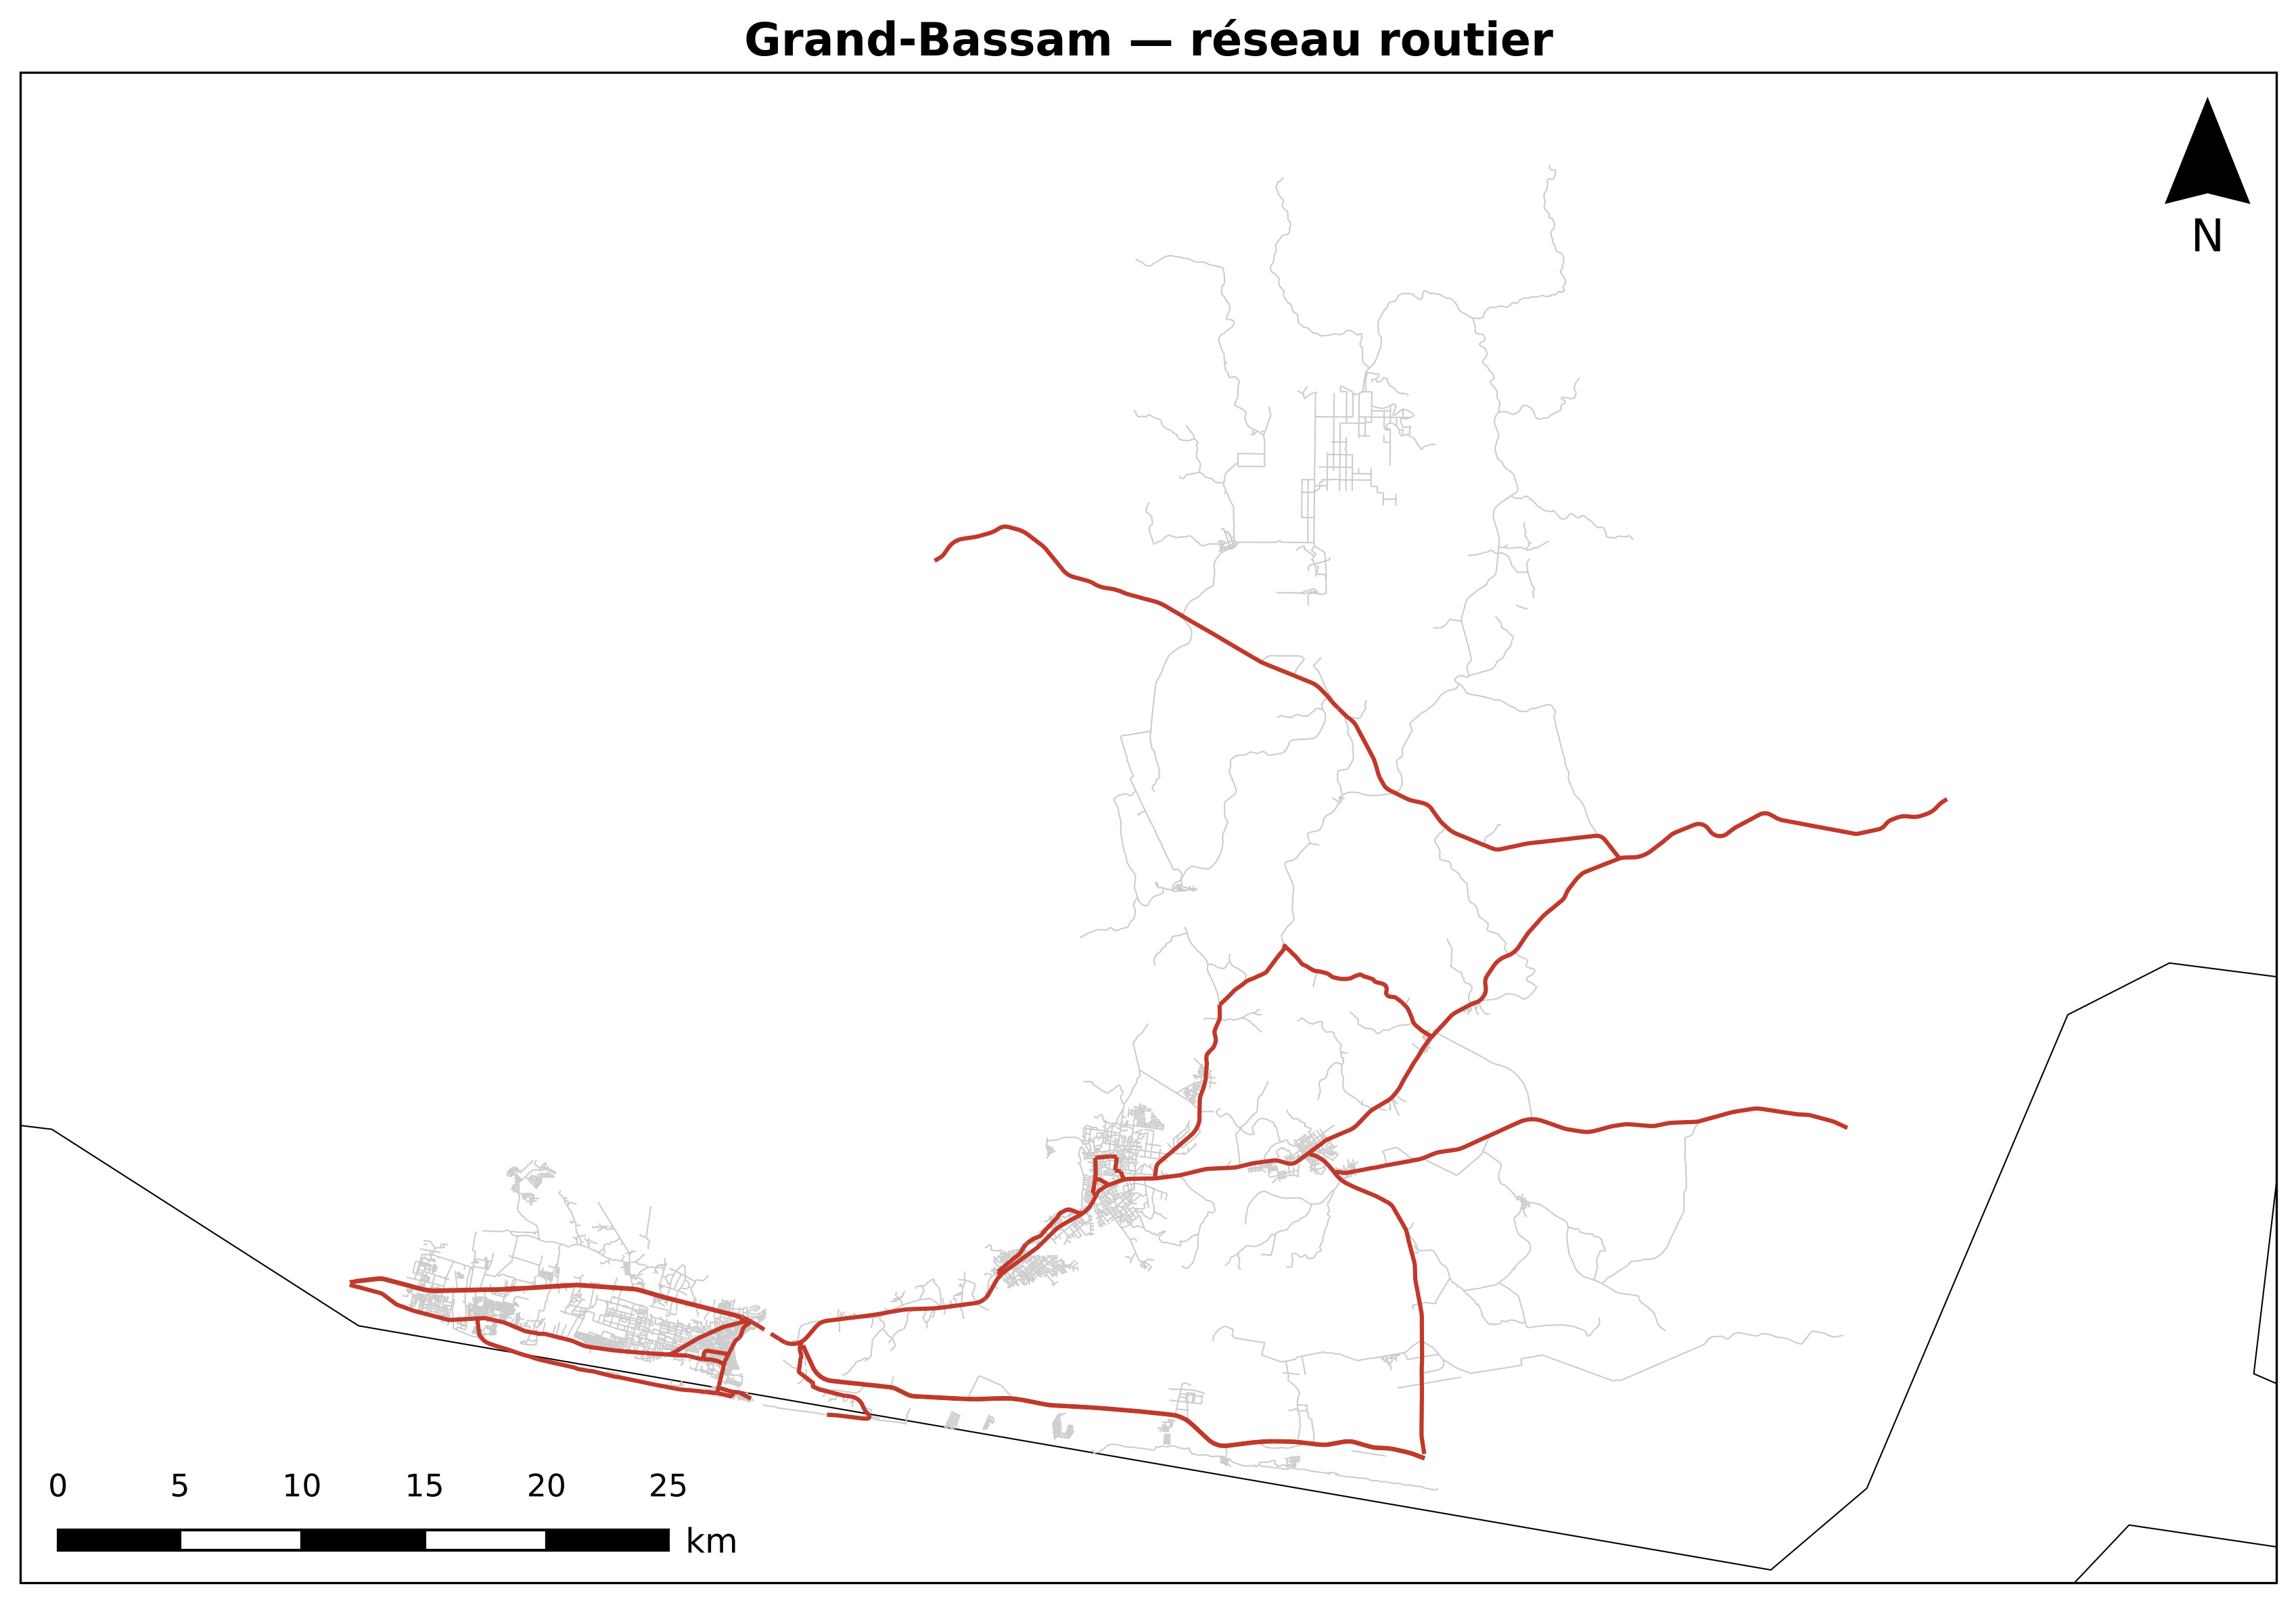

In [5]:
# Uniquement les axes structurants
axes = osm.get_data(
    PLACE,
    {"highway": ["primary", "secondary", "tertiary", "trunk"]},
    data_type="lines",
)

m = cp.Map(title="Grand-Bassam — réseau routier")
m.add_lines(routes, color="#cccccc", linewidth=0.5)
m.add_lines(axes, color="#c0392b", linewidth=1.5)
m.add_north_arrow()
m.add_scale_bar()
m.show()

## Bâtiments (polygones)

19147 bâtiments


📊 Centrage intelligent appliqué:


   Format: Personnalisé (N/A)


   Ratio figure: 1.50


   Ratio données: 1.21


   Étendue: [-4.00, -3.16, 5.13, 5.68]


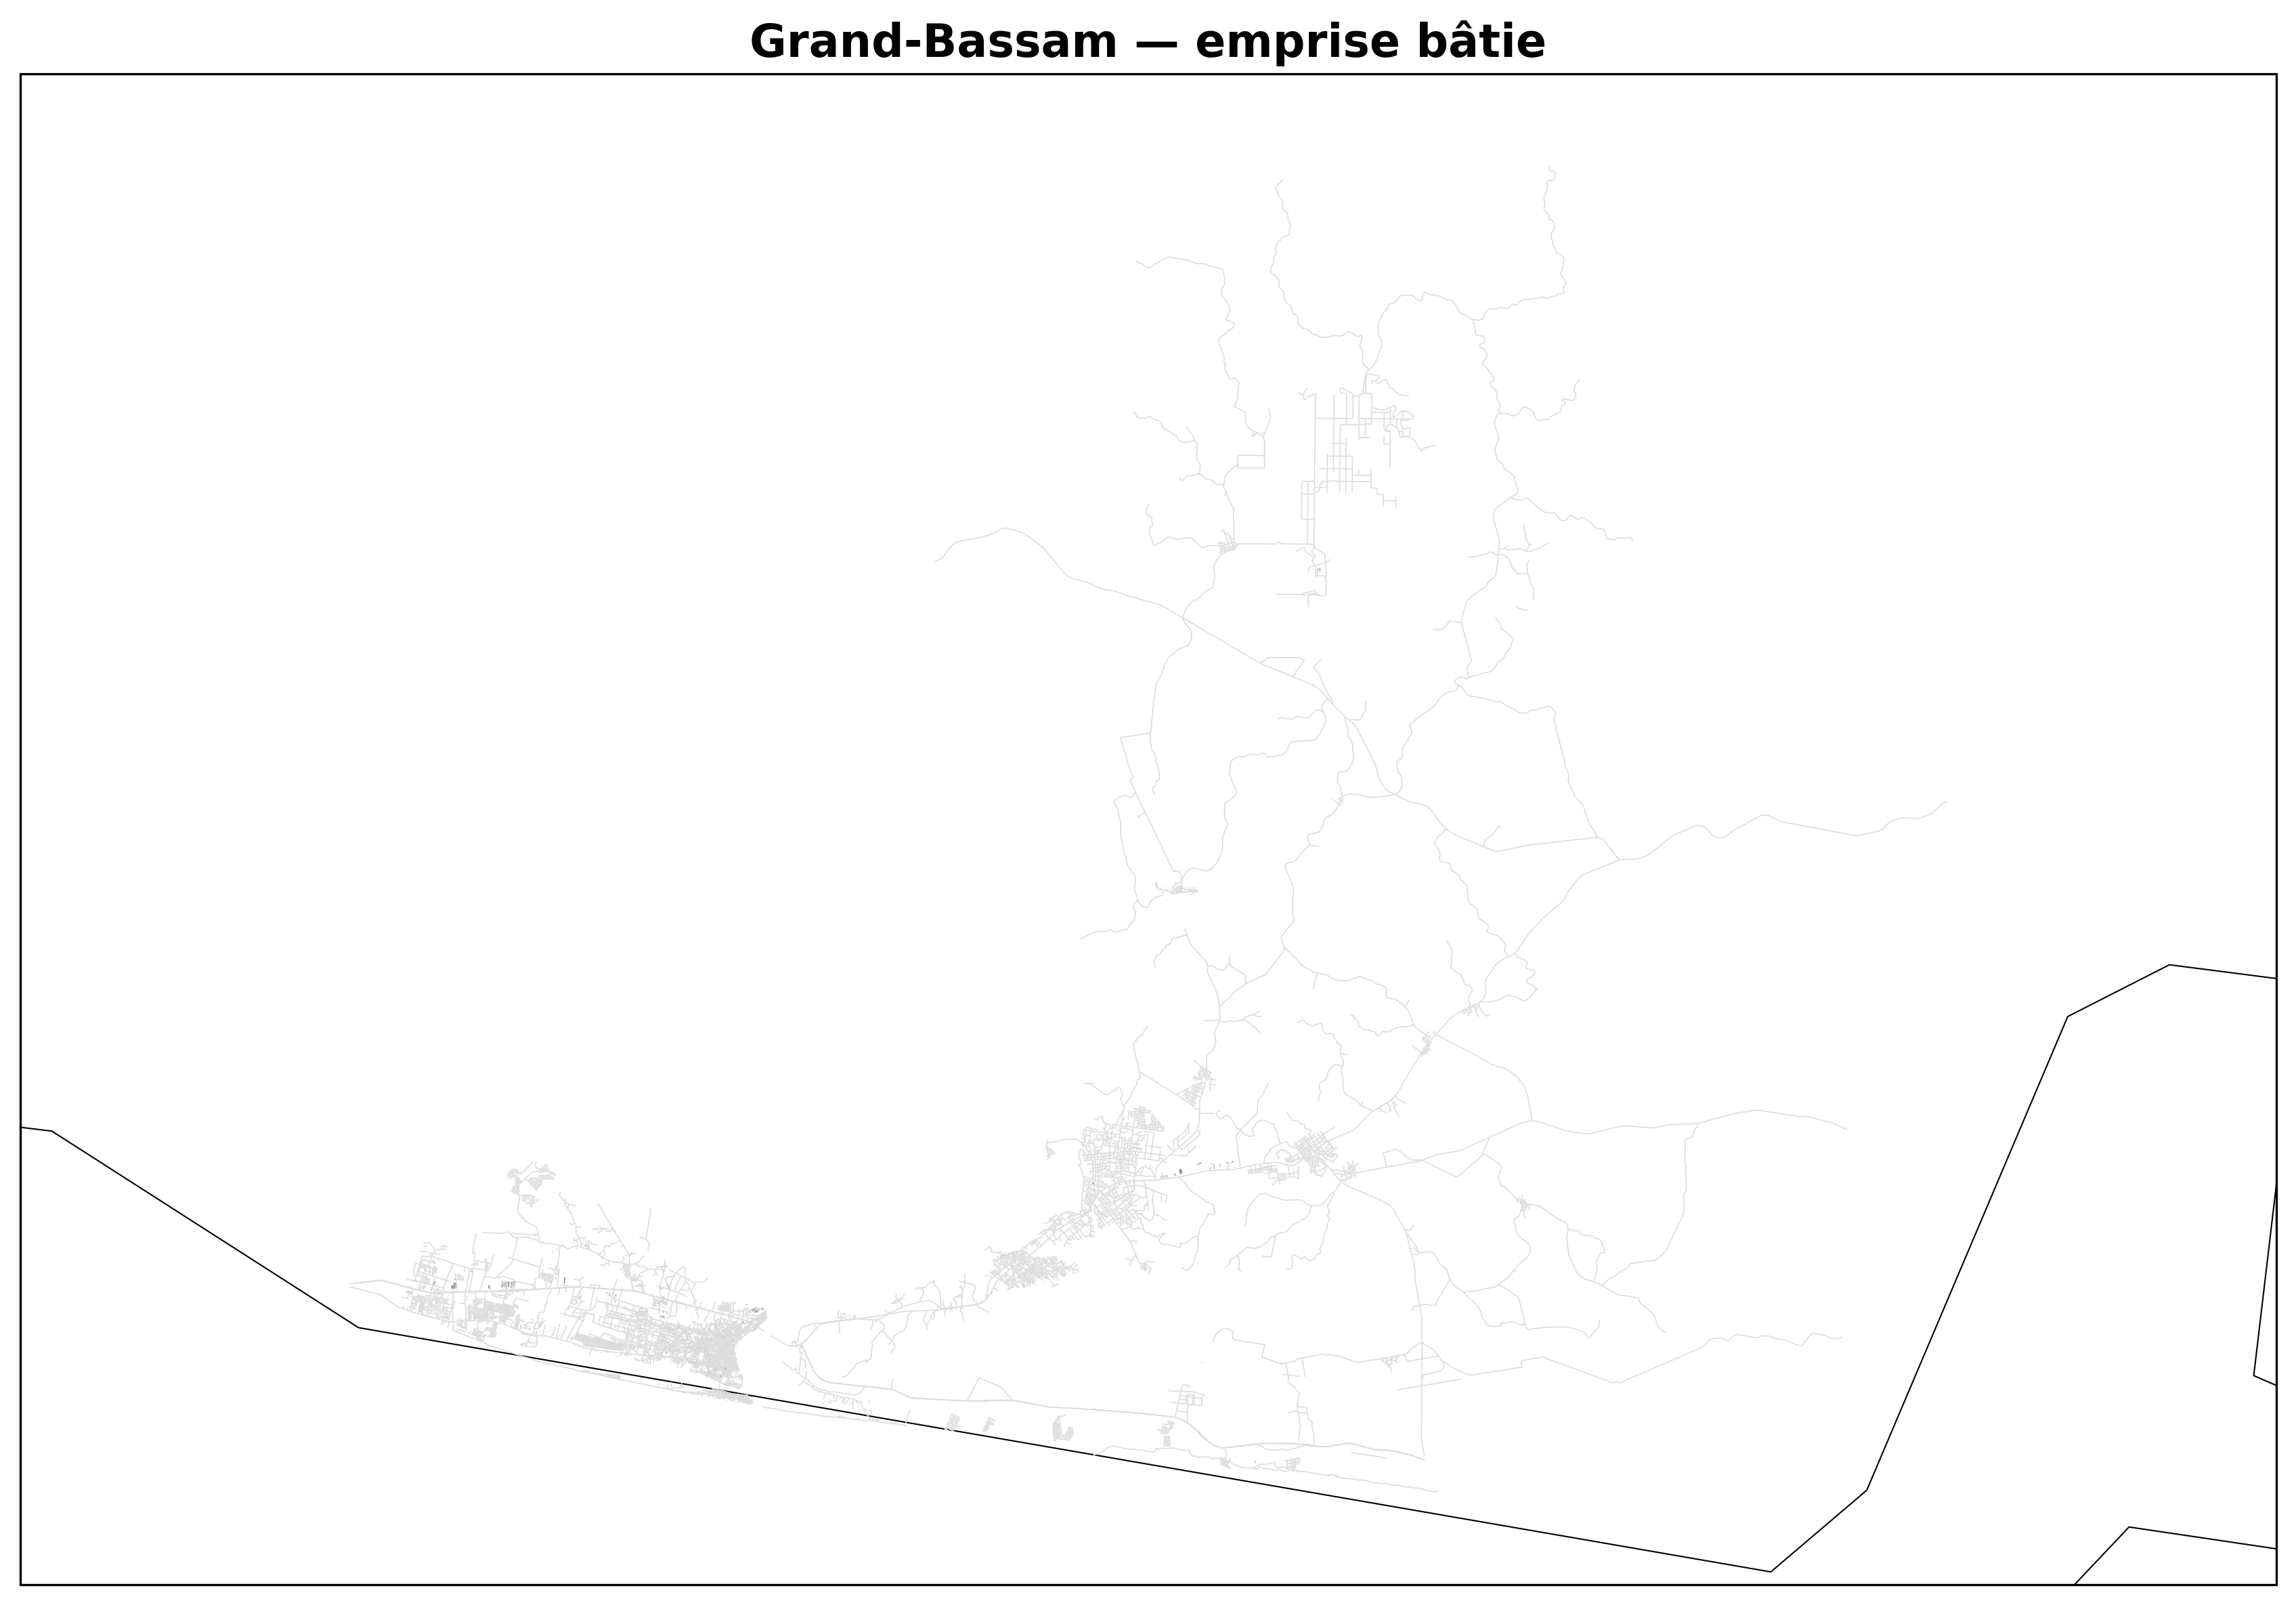

In [6]:
batiments = osm.get_data(PLACE, {"building": True}, data_type="polygons")
print(len(batiments), "bâtiments")

m = cp.Map(title="Grand-Bassam — emprise bâtie")
m.add_lines(routes, color="#dddddd", linewidth=0.4)
m.add_polygons(batiments, facecolor="#7f8c8d", edge_color="none", alpha=0.9)
m.show()

## Hôtels et hébergements (points)

In [7]:
hotels = osm.get_data(
    PLACE,
    {"tourism": ["hotel", "guest_house", "hostel"]},
    data_type="points",
)
cols = [c for c in ["name", "tourism", "geometry"] if c in hotels.columns]
hotels[cols]

name      tourism  \
element id                                                        
node    538901894            La Taverne Bassamoise        hotel   
        843510288                  Hôtel Le Tereso        hotel   
        3095851689                  Madou & Djalai        hotel   
        3294763029                  Ore Luxe Hotel        hotel   
        3296277992                 Auberge N'Zassa        hotel   
        3655054498                     Royal Hotel        hotel   
        3750000695            Foyer Hôtel Infinity        hotel   
        3750009854                    Hôtel Jubilé        hotel   
        3750009963                Hôtel Manou & Jo        hotel   
        3750024266               Auberge du compte        hotel   
        3771261564                  Mantchan Hôtel        hotel   
        3905170501             Residence Boursault        hotel   
        3916603816             La Bonne Fourchette        hotel   
        3916603821         West Beach - Restaurant        hotel   
        3916605793                       Saint Cyr        hotel   
        3916608103      Auberge les 3 cocotiers Pv        hotel   
        3916609138       Mahaba la cour des grands        hotel   
        3916609384                   Boblin la Mer        hotel   
        3916609385                        Capricio        hotel   
        3916609530                Paradis Tropical        hotel   
        3916609531                    Drogba Beach        hotel   
        3916609532                    Le Binguiste        hotel   
        3916609533                Saveur des anges       hostel   
        3928802982               Hôtel La Capitale        hotel   
        3929742252                    Clos fleuris        hotel   
        3931987802            Hôtel Palmier Bassam        hotel   
        3932121199                        Hôtel 3G        hotel   
        3980346172           Résidence Hôtel Kelso        hotel   
        3980346732                     Hôtel St JO        hotel   
        3980347154                     Nieba Hôtel        hotel   
        4383332391                   Aliekro Hôtel        hotel   
        5037866228            Coconut’s City Lodge        hotel   
        5077552222                     Maison NAHO       hostel   
        5270427622   Résidence Hotel Nirala bonoua        hotel   
        5346673921          La Maison de La Lagune        hotel   
        5645922021                 Océan et Lagune        hotel   
        5745696824              Maison Maman marie  guest_house   
        6032293386          Nouvelle maison Bonoua        hotel   
        6183265586                             NaN        hotel   
        6643078716                   Jardin d'Eden        hotel   
        6742272487             The Elephants Nests       hostel   
        6743753647                  Prestige hôtel        hotel   
        7813567911                   Sabbath plage        hotel   
        9975557574                   Hôtel Suprême        hotel   
        10604907505                            NaN  guest_house   
        10785319905                            NaN        hotel   
        10855565405               Aka Gnamke Hotel        hotel   
        11097058105             COUR ROYALE BONOUA  guest_house   
        11381886209                        Château        hotel   
        11381893388                          YOSSA        hotel   
        11381893389                           Yams        hotel   
        11381899595                        Balanon        hotel   
        13374009901                            NaN        hotel   
        13409245001                  maison Marino        hotel   

                                     geometry  
element id                                     
node    538901894     POINT (-3.73993 5.1956)  
        843510288    POINT (-3.74711 5.19662)  
        3095851689   POINT (-3.76921 5.21805)  
        3294763029   POINT (-3.61905 5.23935)  
     

## Commodités : restaurants, pharmacies, écoles…

Une valeur de tag peut être une liste. `data_type="all"` garde points ET
polygones (un hôpital est parfois cartographié comme surface).

In [8]:
amenites = osm.get_data(
    PLACE,
    {"amenity": ["restaurant", "cafe", "pharmacy", "school", "bank", "fuel"]},
    data_type="all",
)
amenites["amenity"].value_counts()

amenity
restaurant    80
school        44
pharmacy      24
bank          18
fuel          14
cafe           4
Name: count, dtype: int64

C:\Users\Ordinateur\AppData\Local\Temp\ipykernel_21808\2934834120.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  pts["geometry"] = pts.geometry.centroid


📊 Centrage intelligent appliqué:


   Format: Personnalisé (N/A)


   Ratio figure: 1.50


   Ratio données: 1.21


   Étendue: [-4.00, -3.16, 5.13, 5.68]


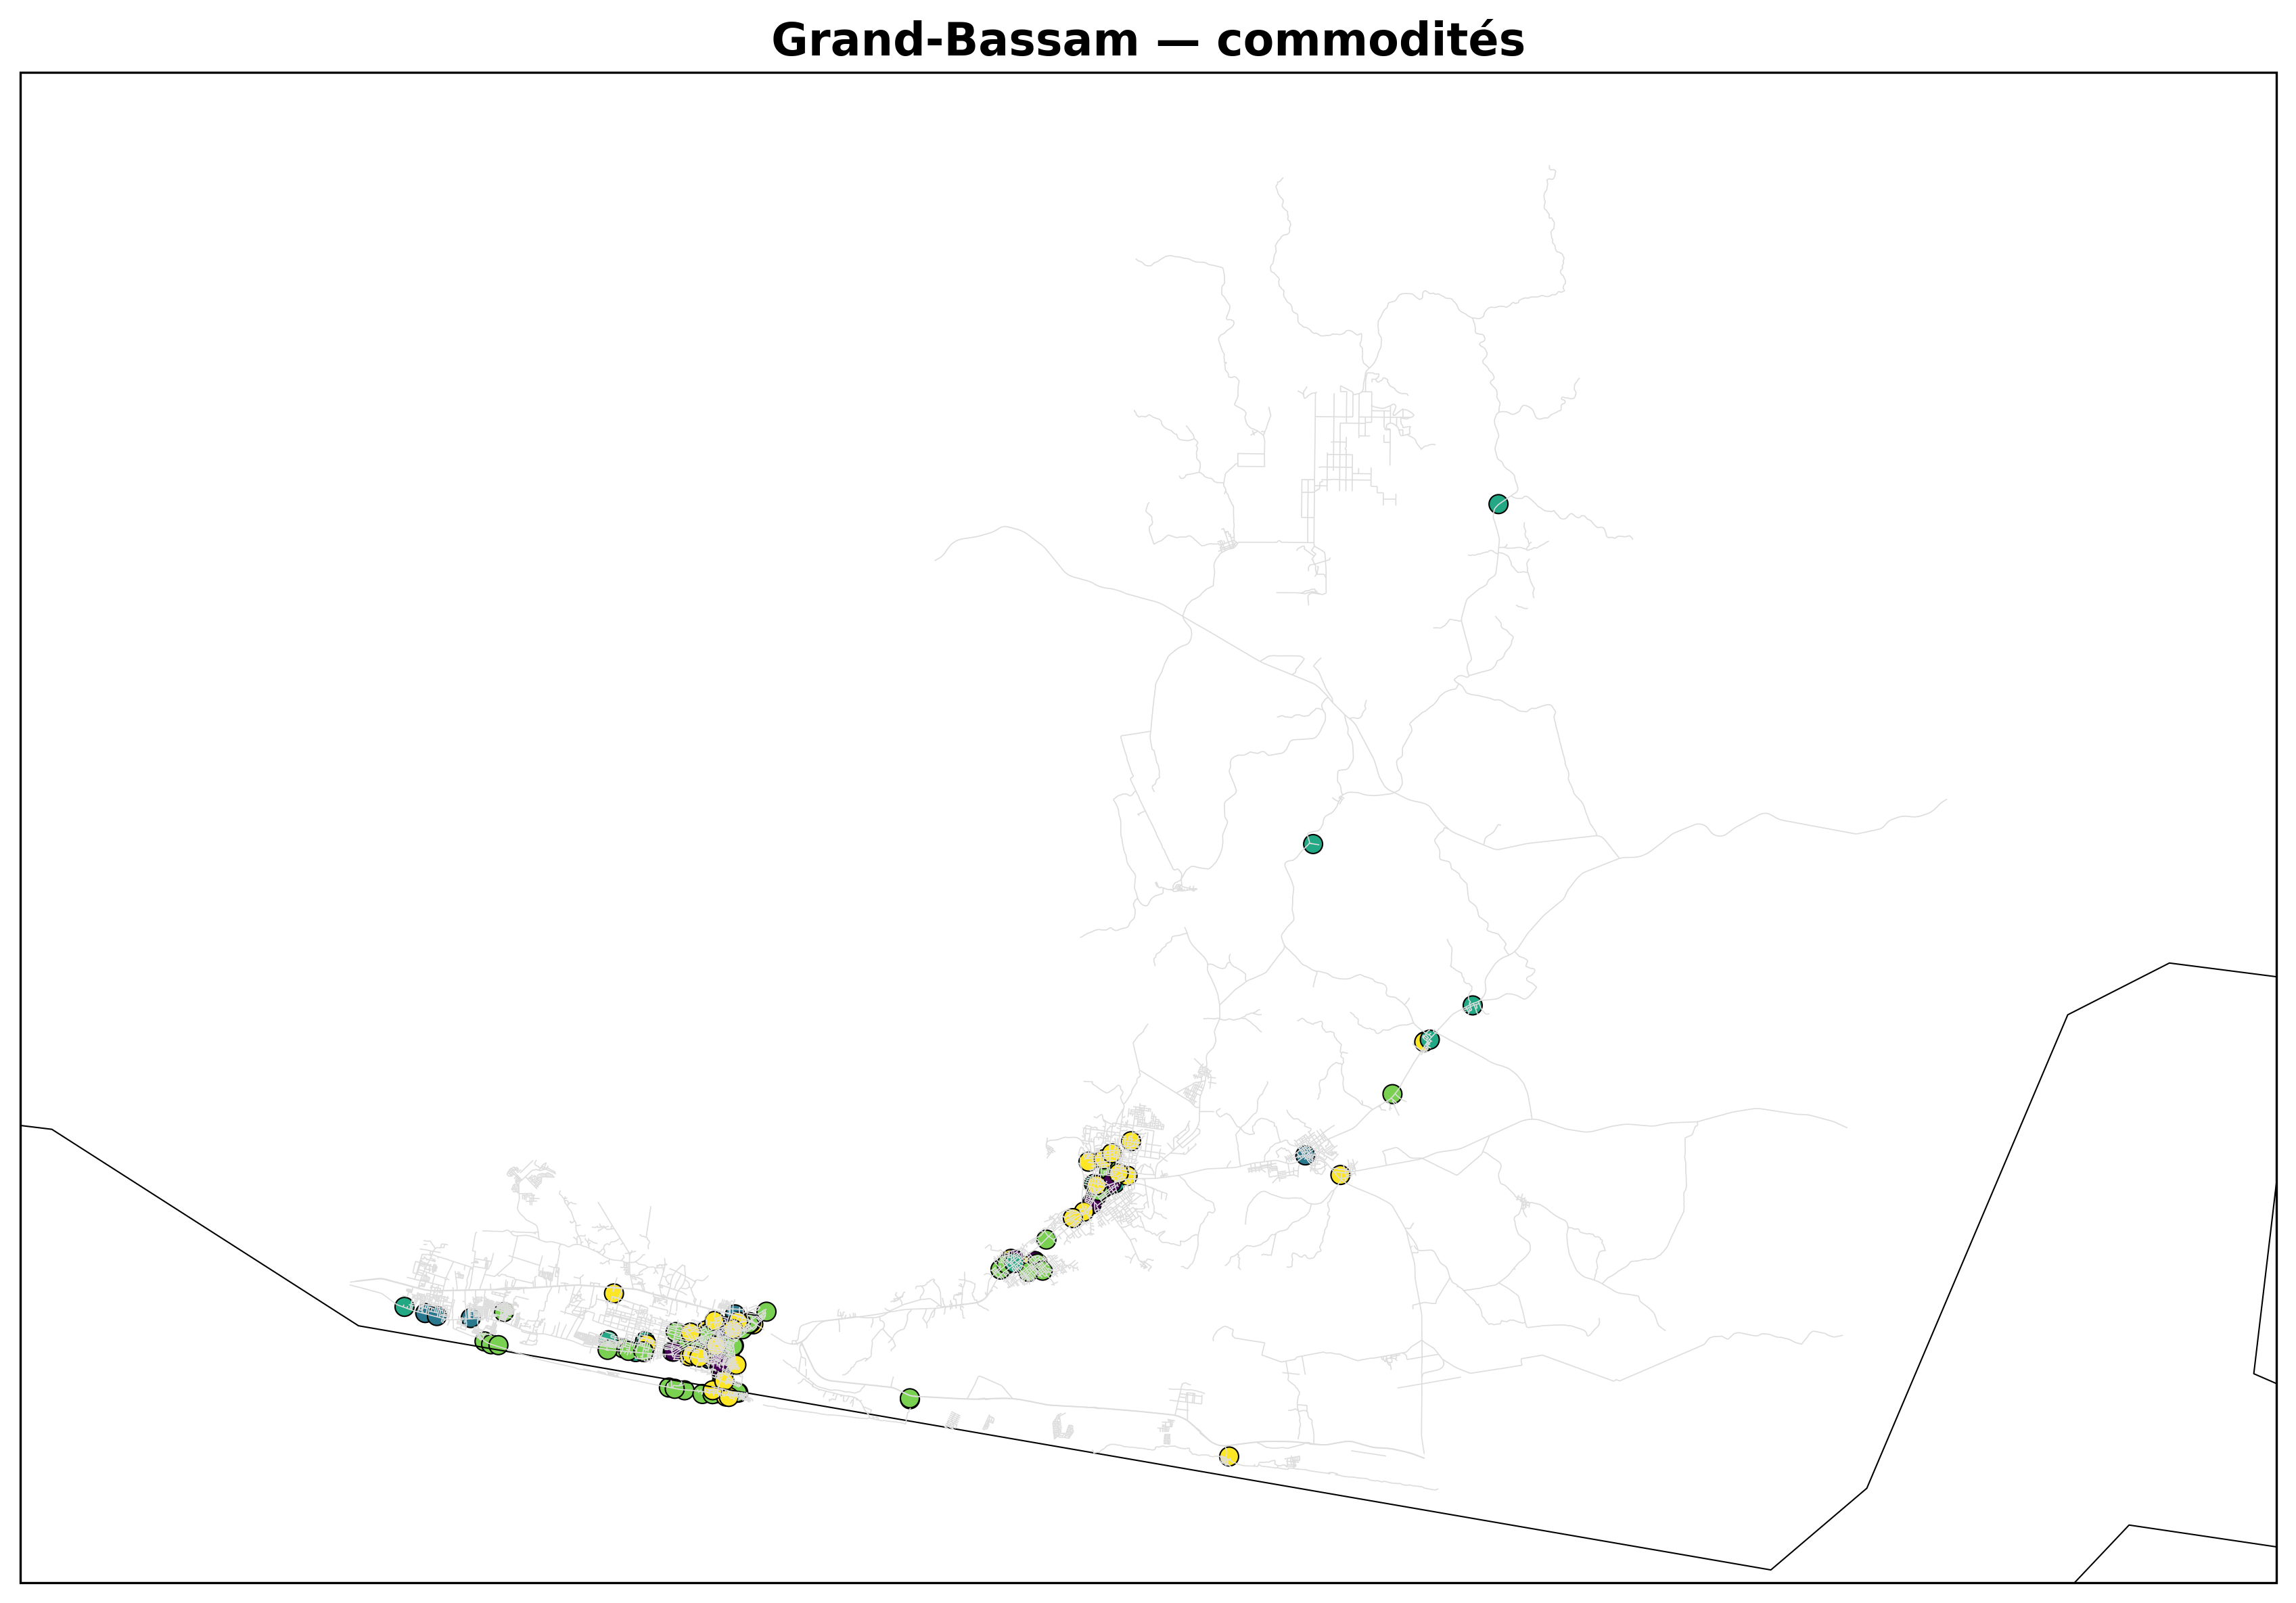

In [9]:
# Ramener les polygones à leur centroïde pour tout afficher en points
pts = amenites.copy()
pts["geometry"] = pts.geometry.centroid

m = cp.Map(title="Grand-Bassam — commodités")
m.add_lines(routes, color="#dddddd", linewidth=0.4)
m.add_points(pts, column="amenity", size=45)
m.show()

## Autres entrées : bbox et GeoDataFrame

Au lieu d'un nom de lieu, `place` peut être une **bounding box**
`(ouest, sud, est, nord)`…

In [10]:
bbox = (-3.745, 5.195, -3.720, 5.215)  # centre historique de Grand-Bassam
eau = osm.get_data(bbox, {"natural": "water", "waterway": True}, data_type="all")
print(len(eau), "objets hydrographiques dans la bbox")

9 objets hydrographiques dans la bbox


In [11]:
# … ou un GeoDataFrame polygonal : la requête est découpée à cette emprise.
import geopandas as gpd
from shapely.geometry import box

zone = gpd.GeoDataFrame(geometry=[box(*bbox)], crs="EPSG:4326")
parcs = osm.get_data(zone, {"leisure": ["park", "garden", "pitch"]}, data_type="polygons")
print(len(parcs), "espaces de loisirs dans la zone")

8 espaces de loisirs dans la zone
